# 16×16 Ising magnetization from spin configurations

This notebook computes magnetization directly from the saved spins, without using the simulator's magnetization columns. For each configuration,

$$m = \frac{1}{L^2}\sum_{i=1}^{L^2} s_i, \qquad |m| = \left|m\right|.$$

The ten configurations at each temperature are averaged within each seed first. The plotted error bar is then the standard error across the 1,000 independent seed means. This keeps the independent simulation seed—not an individual bin—as the unit of replication.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

L = 16
N_SITES = L ** 2
EXPECTED_RUNS = 1_000
EXPECTED_TEMPERATURES = 31
BINS_PER_TEMPERATURE = 10

# This notebook lives in notebooks/ising/. Run it from any working directory.
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parents[1]]
REPO_ROOT = next(root for root in candidate_roots if (root / 'data' / 'raw').exists())
DATA_ROOT = REPO_ROOT / 'data' / 'raw'
OUTPUT_ROOT = REPO_ROOT / 'data' / 'processed'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

REPO_ROOT

PosixPath('/data/lledson/senior thesis')

## Discover and validate the simulation runs

Each run contains one 256-column spin file and a bin file whose temperature rows have the same ordering.

In [2]:
run_dirs = sorted(
    DATA_ROOT.glob('ising16_tc_[0-9]*'),
    key=lambda path: int(path.name.rsplit('_', 1)[1]),
)

assert len(run_dirs) == EXPECTED_RUNS, (
    f'Expected {EXPECTED_RUNS} runs, found {len(run_dirs)} under {DATA_ROOT}'
)

print(f'Found {len(run_dirs):,} independent runs')
print(f'Seed range: {100000:,}–{100000 + len(run_dirs) - 1:,}')

Found 1,000 independent runs
Seed range: 100,000–100,999


## Calculate magnetization from the spins

The spin file has one configuration per row. We sum its 256 values and divide by $16^2$. Both signed $m$ and absolute $|m|$ are retained; $|m|$ is used for the transition curve because finite Ising systems switch between the two symmetry-related magnetized states.

In [3]:
seed_mean_abs_m = np.empty((EXPECTED_RUNS, EXPECTED_TEMPERATURES), dtype=np.float64)
seed_mean_signed_m = np.empty_like(seed_mean_abs_m)
temperatures = None

for run_index, run_dir in enumerate(run_dirs):
    suffix = run_dir.name
    spin_file = run_dir / f'spinConfigs_{suffix}.txt'
    bin_file = run_dir / f'bins_{suffix}.txt'

    spins = np.loadtxt(spin_file, dtype=np.int8)
    row_temperatures = np.loadtxt(bin_file, comments='#', usecols=1)

    expected_rows = EXPECTED_TEMPERATURES * BINS_PER_TEMPERATURE
    if spins.shape != (expected_rows, N_SITES):
        raise ValueError(f'{spin_file}: expected {(expected_rows, N_SITES)}, got {spins.shape}')
    if row_temperatures.shape != (expected_rows,):
        raise ValueError(f'{bin_file}: expected {expected_rows} temperatures')
    if not np.isin(spins, (-1, 1)).all():
        raise ValueError(f'{spin_file}: found values other than -1 and +1')

    temperature_grid = row_temperatures.reshape(
        EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE
    )
    if not np.all(temperature_grid == temperature_grid[:, :1]):
        raise ValueError(f'{bin_file}: bins are not grouped consistently by temperature')
    this_temperatures = temperature_grid[:, 0]

    if temperatures is None:
        temperatures = this_temperatures
    elif not np.array_equal(temperatures, this_temperatures):
        raise ValueError(f'{bin_file}: temperature grid differs from the first run')

    # This is the requested direct calculation: sum all spins and divide by L^2.
    signed_m = spins.sum(axis=1, dtype=np.int32) / N_SITES
    signed_m = signed_m.reshape(EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE)

    seed_mean_signed_m[run_index] = signed_m.mean(axis=1)
    seed_mean_abs_m[run_index] = np.abs(signed_m).mean(axis=1)

    if (run_index + 1) % 100 == 0:
        print(f'Loaded {run_index + 1:,}/{EXPECTED_RUNS:,} runs')

print(f'Loaded {EXPECTED_RUNS * EXPECTED_TEMPERATURES * BINS_PER_TEMPERATURE:,} configurations')

Loaded 100/1,000 runs


Loaded 200/1,000 runs


Loaded 300/1,000 runs


Loaded 400/1,000 runs


Loaded 500/1,000 runs


Loaded 600/1,000 runs


Loaded 700/1,000 runs


Loaded 800/1,000 runs


Loaded 900/1,000 runs


Loaded 1,000/1,000 runs
Loaded 310,000 configurations


## Average over independent seeds

For each temperature, the standard error is $s/\sqrt{N_{\mathrm{seeds}}}$, where $s$ is the sample standard deviation of the 1,000 per-seed averages.

In [4]:
n_seeds = seed_mean_abs_m.shape[0]
mean_abs_m = seed_mean_abs_m.mean(axis=0)
sem_abs_m = seed_mean_abs_m.std(axis=0, ddof=1) / np.sqrt(n_seeds)
mean_signed_m = seed_mean_signed_m.mean(axis=0)
sem_signed_m = seed_mean_signed_m.std(axis=0, ddof=1) / np.sqrt(n_seeds)

summary = pd.DataFrame({
    'temperature': temperatures,
    'mean_abs_magnetization': mean_abs_m,
    'sem_abs_magnetization': sem_abs_m,
    'mean_signed_magnetization': mean_signed_m,
    'sem_signed_magnetization': sem_signed_m,
    'n_seeds': n_seeds,
    'bins_per_seed': BINS_PER_TEMPERATURE,
})

summary

,temperature,mean_abs_magnetization,sem_abs_magnetization,mean_signed_magnetization,sem_signed_magnetization,n_seeds,bins_per_seed
0,1.50,0.986602,0.000126,0.008472,0.009685,1000,10
1,1.60,0.979672,0.000169,0.003847,0.009533,1000,10
2,1.70,0.970178,0.000221,-0.007633,0.009849,1000,10
3,1.80,0.957123,0.000279,-0.000099,0.009563,1000,10
4,1.90,0.938317,0.000394,-0.001886,0.009163,1000,10
5,2.00,0.911761,0.000553,-0.004244,0.008837,1000,10
6,2.05,0.892266,0.000693,-0.005902,0.008889,1000,10
7,2.10,0.867897,0.000894,-0.011431,0.008655,1000,10
8,2.15,0.836354,0.001126,-0.002218,0.008555,1000,10
9,2.18,0.811334,0.001332,-0.009189,0.008288,1000,10


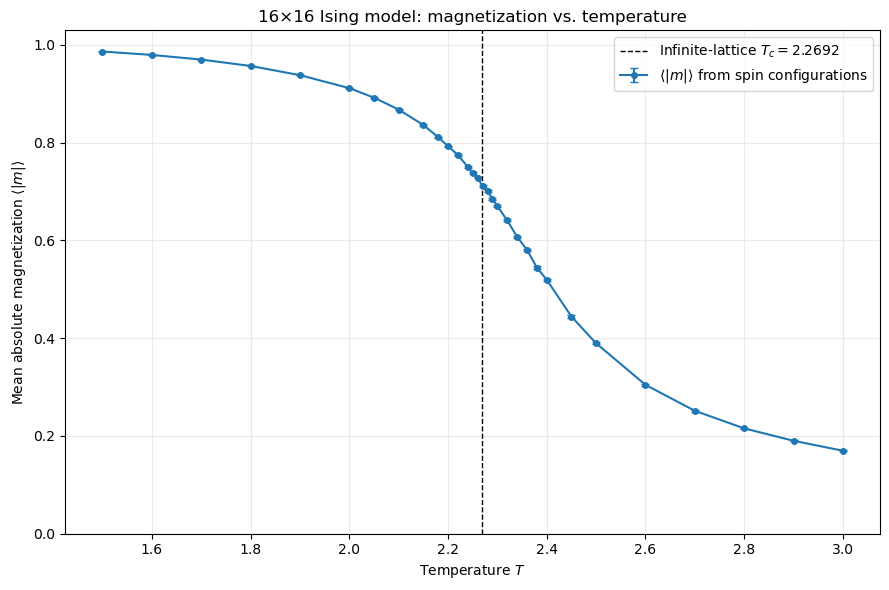

In [5]:
critical_temperature = 2.0 / np.log(1.0 + np.sqrt(2.0))

fig, ax = plt.subplots(figsize=(9, 6))
ax.errorbar(
    summary['temperature'],
    summary['mean_abs_magnetization'],
    yerr=summary['sem_abs_magnetization'],
    fmt='o-',
    markersize=4,
    linewidth=1.5,
    capsize=3,
    label=r'$\langle |m| \rangle$ from spin configurations',
)
ax.axvline(
    critical_temperature,
    color='black',
    linestyle='--',
    linewidth=1,
    label=fr'Infinite-lattice $T_c = {critical_temperature:.4f}$',
)
ax.set(
    xlabel='Temperature $T$',
    ylabel=r'Mean absolute magnetization $\langle |m| \rangle$',
    title='16×16 Ising model: magnetization vs. temperature',
)
ax.set_ylim(0, 1.03)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()

## Save reusable results

The raw simulation outputs remain untouched. The compact summary and publication-resolution plot are written under the ignored `data/processed/` directory.

In [6]:
csv_path = OUTPUT_ROOT / 'ising16_magnetization_summary.csv'
figure_path = OUTPUT_ROOT / 'ising16_magnetization_vs_temperature.png'

summary.to_csv(csv_path, index=False)
fig.savefig(figure_path, dpi=300, bbox_inches='tight')

print(f'Saved {csv_path}')
print(f'Saved {figure_path}')

Saved /data/lledson/senior thesis/data/processed/ising16_magnetization_summary.csv
Saved /data/lledson/senior thesis/data/processed/ising16_magnetization_vs_temperature.png


## Pretrained ResNet-18 embeddings

This section tests whether features learned from natural ImageNet images contain useful structure for Ising configurations **without fine-tuning the network**.

Each 16×16 spin lattice is transformed as follows:

1. Apply a global spin flip when needed so that the majority spin is +1. This quotients out the Ising $\mathbb{Z}_2$ symmetry; the two ordered orientations are physically equivalent.
2. Map spins from $\{-1,+1\}$ to grayscale $\{0,1\}$.
3. Replicate the single channel to RGB, resize to 224×224 with nearest-neighbor interpolation, and use ImageNet normalization.
4. Extract the 512-dimensional activation before ResNet-18's classification layer.

The cached embeddings are written under `data/processed/`, which is ignored by Git.

In [7]:
import time

import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix
from torchvision.models import ResNet18_Weights, resnet18

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 256 if DEVICE.type == 'cuda' else 32
CANONICALIZE_GLOBAL_FLIP = True

EMBEDDING_PATH = OUTPUT_ROOT / 'ising16_resnet18_embeddings.npy'
EMBEDDING_TEMPERATURE_PATH = OUTPUT_ROOT / 'ising16_resnet18_temperatures.npy'
PCA_PATH = OUTPUT_ROOT / 'ising16_resnet18_pca.npy'

print(f'PyTorch {torch.__version__}')
print(f'Embedding device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch 2.6.0+cu124
Embedding device: cuda
GPU: Quadro RTX 5000


### Extract or load 512-dimensional features

The extraction cell is restartable: after the first successful run it loads the cached arrays instead of sending all 310,000 images through ResNet again.

In [8]:
total_configurations = (
    EXPECTED_RUNS * EXPECTED_TEMPERATURES * BINS_PER_TEMPERATURE
)

if EMBEDDING_PATH.exists() and EMBEDDING_TEMPERATURE_PATH.exists():
    embeddings = np.load(EMBEDDING_PATH, mmap_mode='r')
    embedding_temperatures = np.load(EMBEDDING_TEMPERATURE_PATH)
    if embeddings.shape != (total_configurations, 512):
        raise ValueError(f'Unexpected cached embedding shape: {embeddings.shape}')
    print(f'Loaded cached embeddings: {embeddings.shape}')
else:
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = torch.nn.Identity()
    model.eval().to(DEVICE)

    image_mean = torch.tensor(weights.transforms().mean, device=DEVICE).view(1, 3, 1, 1)
    image_std = torch.tensor(weights.transforms().std, device=DEVICE).view(1, 3, 1, 1)

    embeddings = np.empty((total_configurations, 512), dtype=np.float32)
    embedding_temperatures = np.empty(total_configurations, dtype=np.float32)
    offset = 0
    started = time.perf_counter()

    with torch.inference_mode():
        for run_index, run_dir in enumerate(run_dirs):
            suffix = run_dir.name
            spins = np.loadtxt(
                run_dir / f'spinConfigs_{suffix}.txt', dtype=np.int8
            ).reshape(-1, L, L)
            row_temperatures = np.loadtxt(
                run_dir / f'bins_{suffix}.txt', comments='#', usecols=1
            ).astype(np.float32)

            if CANONICALIZE_GLOBAL_FLIP:
                orientation = np.sign(spins.sum(axis=(1, 2), dtype=np.int32))
                orientation[orientation == 0] = 1
                spins = spins * orientation[:, None, None]

            for start in range(0, len(spins), BATCH_SIZE):
                stop = min(start + BATCH_SIZE, len(spins))
                images = torch.from_numpy(spins[start:stop].astype(np.float32))
                images = images.unsqueeze(1).to(DEVICE, non_blocking=True)
                images = (images + 1.0) / 2.0
                images = images.repeat(1, 3, 1, 1)
                images = F.interpolate(images, size=(224, 224), mode='nearest')
                images = (images - image_mean) / image_std

                features = model(images).cpu().numpy()
                batch_length = stop - start
                embeddings[offset:offset + batch_length] = features
                embedding_temperatures[offset:offset + batch_length] = row_temperatures[start:stop]
                offset += batch_length

            if (run_index + 1) % 100 == 0:
                elapsed = time.perf_counter() - started
                rate = offset / elapsed
                print(
                    f'Embedded {run_index + 1:,}/{EXPECTED_RUNS:,} runs '
                    f'({offset:,} images, {rate:,.0f} images/s)'
                )

    if offset != total_configurations:
        raise RuntimeError(f'Embedded {offset} images, expected {total_configurations}')

    np.save(EMBEDDING_PATH, embeddings)
    np.save(EMBEDDING_TEMPERATURE_PATH, embedding_temperatures)
    print(f'Saved embeddings to {EMBEDDING_PATH}')

assert embeddings.shape == (total_configurations, 512)
assert np.isfinite(embeddings).all()
assert np.array_equal(np.unique(embedding_temperatures), temperatures.astype(np.float32))

Loaded cached embeddings: (310000, 512)


### PCA of the frozen ResNet features

PCA is fit to all 310,000 embeddings. The scatter below uses two configurations per temperature per seed (62,000 points) only to keep the rendered figure manageable; no subsampling is used to fit PCA.

In [9]:
if PCA_PATH.exists():
    pca_coordinates = np.load(PCA_PATH)
    print(f'Loaded cached PCA coordinates: {pca_coordinates.shape}')
else:
    pca = PCA(n_components=10, svd_solver='randomized', random_state=42)
    pca_coordinates = pca.fit_transform(np.asarray(embeddings))
    np.save(PCA_PATH, pca_coordinates.astype(np.float32))
    print(f'Saved PCA coordinates to {PCA_PATH}')

# Refit the small PCA object when coordinates came from cache so its variance is reported.
if 'pca' not in globals():
    pca = PCA(n_components=10, svd_solver='randomized', random_state=42)
    pca.fit(np.asarray(embeddings))

print('Explained variance ratios:', np.round(pca.explained_variance_ratio_[:5], 4))
print(f'Variance in PC1 + PC2: {pca.explained_variance_ratio_[:2].sum():.2%}')

Loaded cached PCA coordinates: (310000, 10)


Explained variance ratios: [0.5131 0.2189 0.0329 0.0261 0.014 ]
Variance in PC1 + PC2: 73.20%


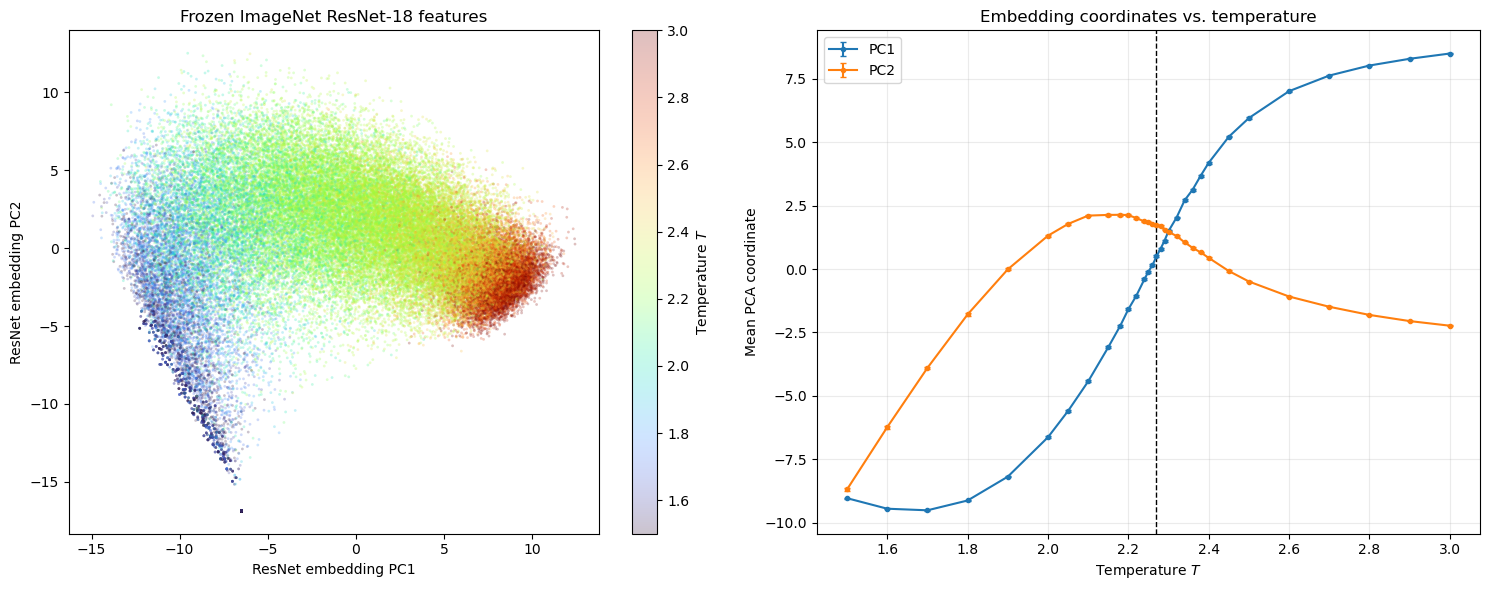

In [10]:
coordinates_grid = pca_coordinates.reshape(
    EXPECTED_RUNS, EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE, -1
)
temperature_grid = embedding_temperatures.reshape(
    EXPECTED_RUNS, EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE
)

# Two deterministic bin samples per temperature and seed for a readable scatter.
display_coordinates = coordinates_grid[:, :, [0, 5], :2].reshape(-1, 2)
display_temperatures = temperature_grid[:, :, [0, 5]].reshape(-1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
scatter = axes[0].scatter(
    display_coordinates[:, 0],
    display_coordinates[:, 1],
    c=display_temperatures,
    cmap='turbo',
    s=4,
    alpha=0.25,
    linewidths=0,
    rasterized=True,
)
axes[0].set(
    xlabel='ResNet embedding PC1',
    ylabel='ResNet embedding PC2',
    title='Frozen ImageNet ResNet-18 features',
)
fig.colorbar(scatter, ax=axes[0], label='Temperature $T$')

# Average bins within seed, then show the seed-level mean and SEM at each T.
seed_temperature_pca = coordinates_grid.mean(axis=2)
mean_pca = seed_temperature_pca.mean(axis=0)
sem_pca = seed_temperature_pca.std(axis=0, ddof=1) / np.sqrt(EXPECTED_RUNS)

axes[1].errorbar(
    temperatures,
    mean_pca[:, 0],
    yerr=sem_pca[:, 0],
    marker='o',
    markersize=3,
    capsize=2,
    label='PC1',
)
axes[1].errorbar(
    temperatures,
    mean_pca[:, 1],
    yerr=sem_pca[:, 1],
    marker='o',
    markersize=3,
    capsize=2,
    label='PC2',
)
axes[1].axvline(critical_temperature, color='black', linestyle='--', linewidth=1)
axes[1].set(
    xlabel='Temperature $T$',
    ylabel='Mean PCA coordinate',
    title='Embedding coordinates vs. temperature',
)
axes[1].grid(alpha=0.25)
axes[1].legend()

fig.tight_layout()
embedding_figure_path = OUTPUT_ROOT / 'ising16_resnet18_pca.png'
fig.savefig(embedding_figure_path, dpi=250, bbox_inches='tight')

### Quantify phase information with a frozen-feature linear probe

A visualization can look separated even when information is weak. As a quantitative check, a logistic regression is trained on frozen ResNet embeddings to classify configurations below versus above the exact critical temperature. Seeds 0–799 are used for training and seeds 800–999 for testing, so configurations from one simulation seed never appear on both sides of the split. No ResNet weights are updated.

In [11]:
embedding_grid = np.asarray(embeddings).reshape(
    EXPECTED_RUNS, EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE, 512
)
phase_grid = (temperature_grid > critical_temperature).astype(np.int8)

train_embeddings = embedding_grid[:800].reshape(-1, 512)
train_phase = phase_grid[:800].reshape(-1)
test_embeddings = embedding_grid[800:].reshape(-1, 512)
test_phase = phase_grid[800:].reshape(-1)

linear_probe = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
linear_probe.fit(train_embeddings, train_phase)
predicted_phase = linear_probe.predict(test_embeddings)

probe_accuracy = accuracy_score(test_phase, predicted_phase)
probe_balanced_accuracy = balanced_accuracy_score(test_phase, predicted_phase)
probe_confusion = confusion_matrix(test_phase, predicted_phase)

print(f'Test accuracy:          {probe_accuracy:.3%}')
print(f'Test balanced accuracy: {probe_balanced_accuracy:.3%}')
print('Confusion matrix [[ordered, predicted], [disordered, predicted]]:')
print(probe_confusion)

Test accuracy:          82.452%
Test balanced accuracy: 82.464%
Confusion matrix [[ordered, predicted], [disordered, predicted]]:
[[24858  5142]
 [ 5738 26262]]


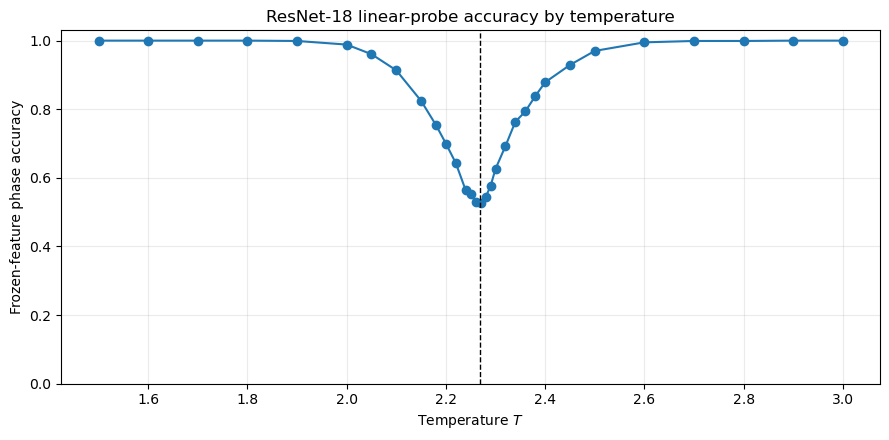

In [12]:
# Temperature-resolved probe accuracy shows where ambiguity is concentrated.
test_temperature = temperature_grid[800:].reshape(-1)
temperature_accuracy = pd.DataFrame({
    'temperature': test_temperature,
    'correct': predicted_phase == test_phase,
}).groupby('temperature', as_index=False)['correct'].mean()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(temperature_accuracy['temperature'], temperature_accuracy['correct'], 'o-')
ax.axvline(critical_temperature, color='black', linestyle='--', linewidth=1)
ax.set(
    xlabel='Temperature $T$',
    ylabel='Frozen-feature phase accuracy',
    ylim=(0, 1.03),
    title='ResNet-18 linear-probe accuracy by temperature',
)
ax.grid(alpha=0.25)
fig.tight_layout()

probe_figure_path = OUTPUT_ROOT / 'ising16_resnet18_phase_probe.png'
fig.savefig(probe_figure_path, dpi=250, bbox_inches='tight')
plt.show()
plt.close(fig)

## What ResNet-18 sees across the temperature sweep

This grid uses one simulation seed and one saved bin at each of the 31 temperatures. Every panel passes through the same preprocessing used for the embedding analysis:

1. Canonicalize the global spin-flip symmetry so the majority spin is +1.
2. Map $-1 \mapsto 0$ and $+1 \mapsto 1$.
3. Replicate the lattice into three RGB channels.
4. Resize 16×16 to 224×224 with nearest-neighbor interpolation.
5. Apply ImageNet channel normalization.

For human readability, the displayed panels are de-normalized back to RGB after constructing the exact normalized tensors. Thus the pixels and resize are exactly what ResNet receives, while black and white remain visually interpretable.

In [13]:
DISPLAY_SEED = 100000
DISPLAY_BIN = 0  # zero-based: choose one of the ten saved bins per temperature

display_run_index = DISPLAY_SEED - 100000
if not 0 <= display_run_index < EXPECTED_RUNS:
    raise ValueError(f'Seed must be between 100000 and 100999, got {DISPLAY_SEED}')
if not 0 <= DISPLAY_BIN < BINS_PER_TEMPERATURE:
    raise ValueError(f'Bin must be between 0 and {BINS_PER_TEMPERATURE - 1}')

display_run_dir = run_dirs[display_run_index]
display_suffix = display_run_dir.name
display_spins = np.loadtxt(
    display_run_dir / f'spinConfigs_{display_suffix}.txt', dtype=np.int8
).reshape(EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE, L, L)
display_row_temperatures = np.loadtxt(
    display_run_dir / f'bins_{display_suffix}.txt', comments='#', usecols=1
).reshape(EXPECTED_TEMPERATURES, BINS_PER_TEMPERATURE)

temperature_sweep_spins = display_spins[:, DISPLAY_BIN].copy()
temperature_sweep = display_row_temperatures[:, DISPLAY_BIN]

if CANONICALIZE_GLOBAL_FLIP:
    orientation = np.sign(temperature_sweep_spins.sum(axis=(1, 2), dtype=np.int32))
    orientation[orientation == 0] = 1
    temperature_sweep_spins *= orientation[:, None, None]

resnet_sweep_input = torch.from_numpy(
    temperature_sweep_spins.astype(np.float32)
).unsqueeze(1).to(DEVICE)
resnet_sweep_input = (resnet_sweep_input + 1.0) / 2.0
resnet_sweep_input = resnet_sweep_input.repeat(1, 3, 1, 1)
resnet_sweep_input = F.interpolate(
    resnet_sweep_input, size=(224, 224), mode='nearest'
)

resnet_weights = ResNet18_Weights.DEFAULT
resnet_mean = torch.tensor(
    resnet_weights.transforms().mean, device=DEVICE
).view(1, 3, 1, 1)
resnet_std = torch.tensor(
    resnet_weights.transforms().std, device=DEVICE
).view(1, 3, 1, 1)
resnet_sweep_input = (resnet_sweep_input - resnet_mean) / resnet_std

# Undo only channel normalization for display; the RGB replication and 224×224
# nearest-neighbor pixels remain exactly those supplied to ResNet.
visible_sweep = (resnet_sweep_input * resnet_std + resnet_mean).clamp(0, 1)
visible_sweep = visible_sweep.cpu().permute(0, 2, 3, 1).numpy()

print(f'Exact ResNet input tensor: {tuple(resnet_sweep_input.shape)}')
for channel, name in enumerate(('R', 'G', 'B')):
    values = torch.unique(resnet_sweep_input[:, channel]).cpu().numpy()
    print(f'{name}-channel normalized values: {values}')

Exact ResNet input tensor: (31, 3, 224, 224)
R-channel normalized values: [-2.117904   2.2489083]
G-channel normalized values: [-2.0357141  2.4285715]
B-channel normalized values: [-1.8044444  2.64     ]


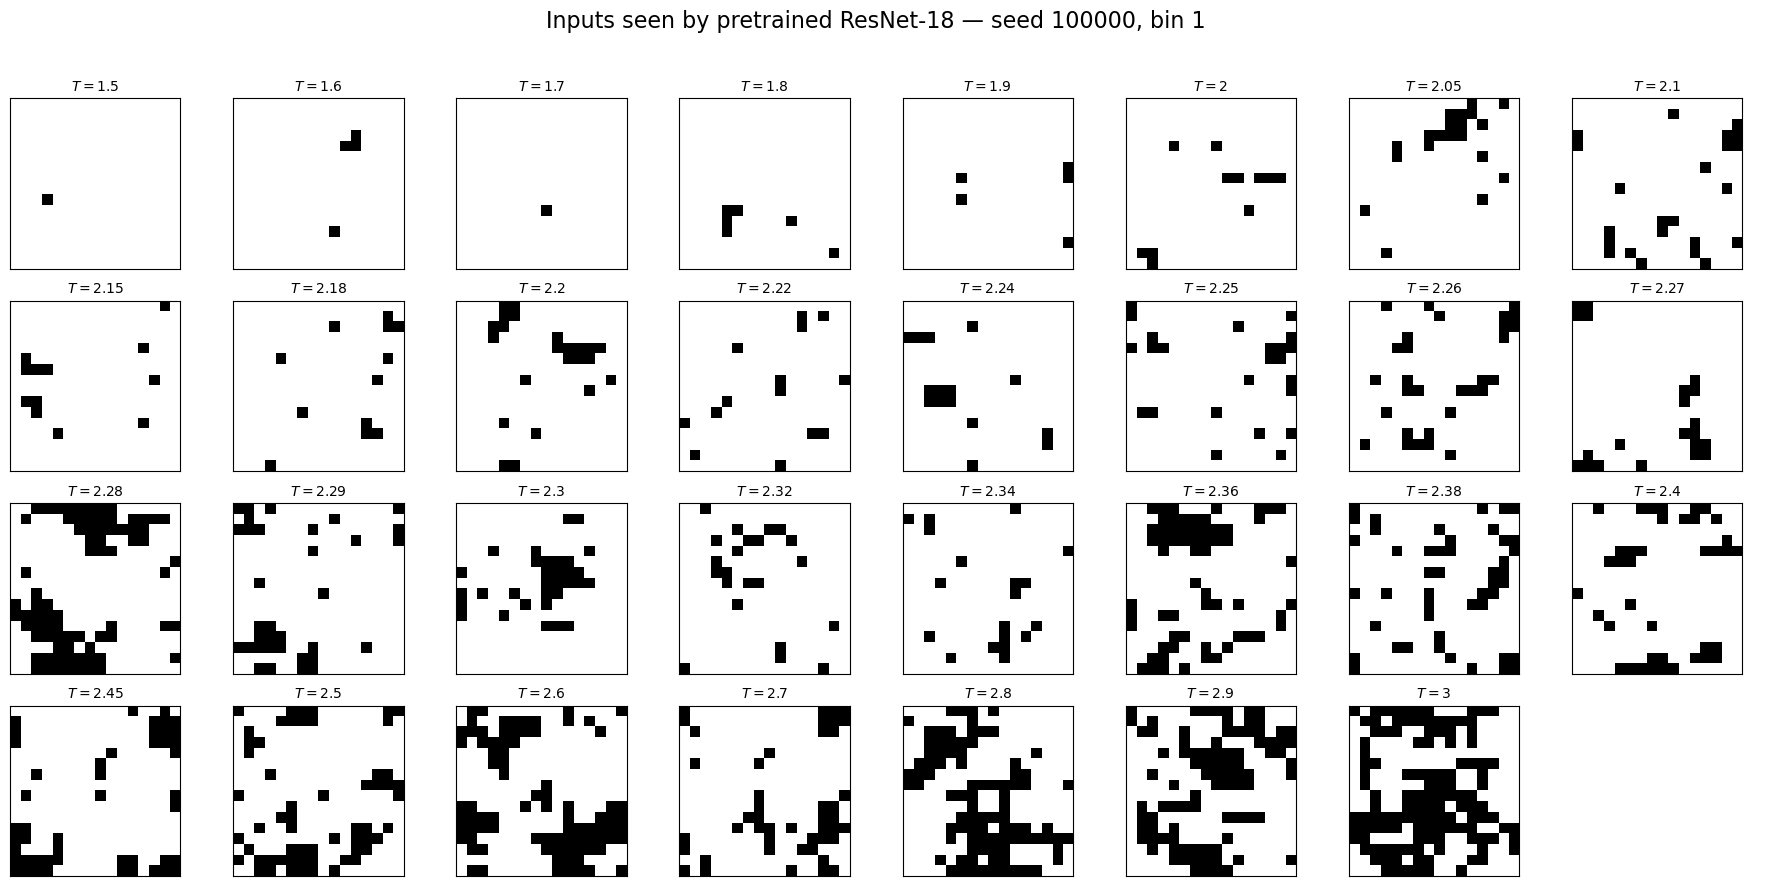

Saved /data/lledson/senior thesis/data/processed/ising16_resnet18_input_sweep_seed_100000.png


In [14]:
fig, axes = plt.subplots(4, 8, figsize=(18, 9))
axes = axes.ravel()

for index, (image, temperature) in enumerate(zip(visible_sweep, temperature_sweep)):
    axes[index].imshow(image, interpolation='nearest')
    axes[index].set_title(f'$T={temperature:g}$', fontsize=10)
    axes[index].set_xticks([])
    axes[index].set_yticks([])

for axis in axes[len(visible_sweep):]:
    axis.axis('off')

fig.suptitle(
    f'Inputs seen by pretrained ResNet-18 — seed {DISPLAY_SEED}, bin {DISPLAY_BIN + 1}',
    fontsize=16,
)
fig.tight_layout(rect=(0, 0, 1, 0.96))

resnet_sweep_path = OUTPUT_ROOT / f'ising16_resnet18_input_sweep_seed_{DISPLAY_SEED}.png'
fig.savefig(resnet_sweep_path, dpi=220, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved {resnet_sweep_path}')